# EDA ChestMNIST

Objectif : vérifier les dimensions, les splits officiels et le déséquilibre des 14 labels avant l'entraînement.

In [1]:
from pathlib import Path
import sys
sys.path.append(str(Path('..').resolve()))

import matplotlib.pyplot as plt
import numpy as np
import yaml

from src.data.chestmnist_dataset import CHESTMNIST_LABELS, get_chestmnist_dataset

with open('../config.yaml', 'r', encoding='utf-8') as f:
    config = yaml.safe_load(f)

datasets = {
    split: get_chestmnist_dataset(split, '../' + config['paths']['data_root'], config['chestmnist']['size'])
    for split in ['train', 'val', 'test']
}
{split: len(ds) for split, ds in datasets.items()}

{'train': 78468, 'val': 11219, 'test': 22433}

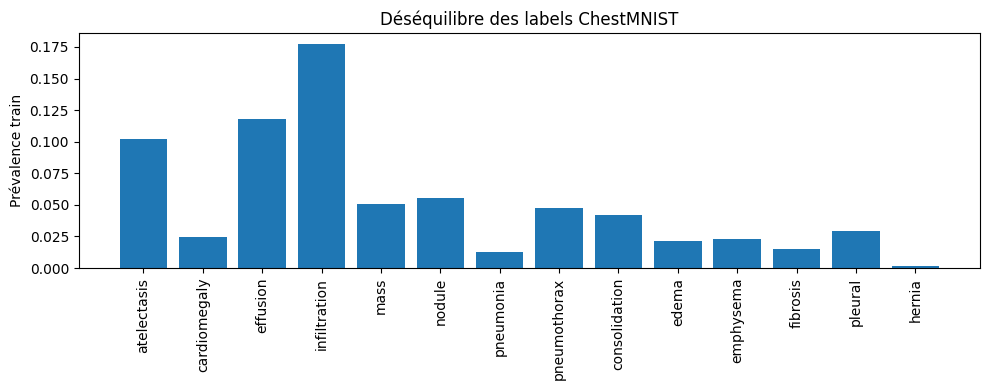

In [2]:
labels = datasets['train'].labels
prevalence = labels.mean(axis=0)
names = list(CHESTMNIST_LABELS.values())

plt.figure(figsize=(10, 4))
plt.bar(names, prevalence)
plt.xticks(rotation=90)
plt.ylabel('Prévalence train')
plt.title('Déséquilibre des labels ChestMNIST')
plt.tight_layout()
plt.show()

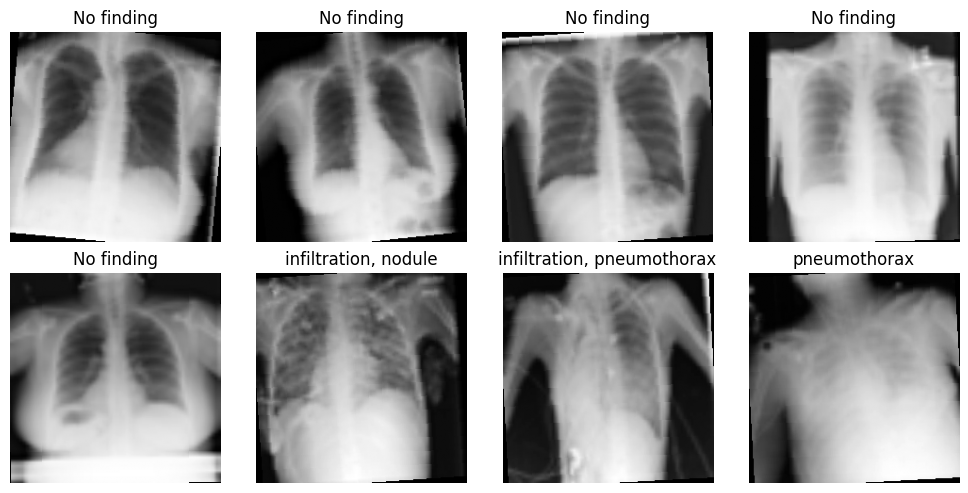

In [3]:
fig, axes = plt.subplots(2, 4, figsize=(10, 5))
for ax, idx in zip(axes.ravel(), range(8)):
    image, target = datasets['train'][idx]
    ax.imshow(image.squeeze(), cmap='gray')
    positive = [names[i] for i, v in enumerate(target) if v == 1]
    ax.set_title(', '.join(positive[:2]) if positive else 'No finding')
    ax.axis('off')
plt.tight_layout()
plt.show()

À commenter dans le rapport : classes rares, co-occurrences possibles, et intérêt des métriques macro/AUC plutôt que l'accuracy brute.